# Linear Regression với GPU trên Google Colab

## Hướng dẫn Setup Colab trước khi chạy:

### Bước 1 - Bật GPU:
```
Menu: Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save
```

### Bước 2 - Lưu notebook vào Google Drive (khuyến nghị):
```
Menu: File → Save a copy in Drive
→ Notebook sẽ được lưu vào thư mục "Colab Notebooks" trong Drive của bạn
```

### Bước 3 - Chọn kernel:
```
Colab tự động dùng Python 3 kernel, không cần chọn thêm gì.
Nếu thấy nút "Connect" góc trên phải → click vào để kết nối runtime.
```

---
## Bước 1: Kiểm tra GPU có sẵn không

In [1]:
import torch

# Kiểm tra GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU sẵn sàng: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️  Không có GPU, đang dùng CPU")
    print("   → Vào Runtime > Change runtime type > T4 GPU để bật GPU")

print(f"\nDevice đang dùng: {device}")

✅ GPU sẵn sàng: Tesla T4
   VRAM: 15.6 GB

Device đang dùng: cuda


In [2]:
# Xem thông tin chi tiết GPU
!nvidia-smi

Mon Mar  2 11:16:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Bước 2: Tạo dữ liệu giả để train

X shape: torch.Size([500, 1]), device: cuda:0
y shape: torch.Size([500, 1]), device: cuda:0


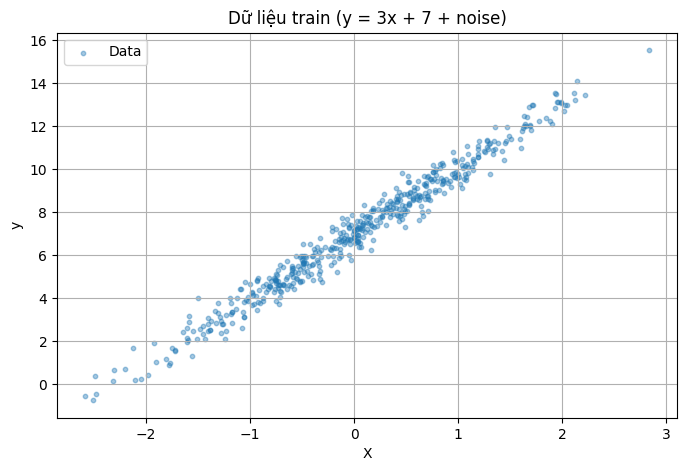

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ---- Tạo dữ liệu: y = 3x + 7 + noise ----
torch.manual_seed(42)
N = 500  # số mẫu

X = torch.randn(N, 1)           # Input: N điểm ngẫu nhiên
y = 3 * X + 7 + 0.5 * torch.randn(N, 1)  # Output: y = 3x + 7 + nhiễu

# Chuyển dữ liệu lên GPU
X = X.to(device)
y = y.to(device)

print(f"X shape: {X.shape}, device: {X.device}")
print(f"y shape: {y.shape}, device: {y.device}")

# Vẽ dữ liệu (cần chuyển về CPU để plot)
plt.figure(figsize=(8, 5))
plt.scatter(X.cpu().numpy(), y.cpu().numpy(), alpha=0.4, s=10, label='Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dữ liệu train (y = 3x + 7 + noise)')
plt.legend()
plt.grid(True)
plt.show()

---
## Bước 3: Định nghĩa mô hình Linear Regression

In [4]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

# Khởi tạo model và đưa lên GPU
model = LinearRegressionModel().to(device)

print("Model architecture:")
print(model)
print(f"\nModel đang chạy trên: {next(model.parameters()).device}")
print(f"\nWeight ban đầu (w): {model.linear.weight.item():.4f}")
print(f"Bias ban đầu  (b): {model.linear.bias.item():.4f}")

Model architecture:
LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Model đang chạy trên: cuda:0

Weight ban đầu (w): -0.2508
Bias ban đầu  (b): -0.8676


---
## Bước 4: Train mô hình trên GPU

In [5]:
import time

# Hyperparameters
learning_rate = 0.01
epochs        = 1000

criterion = nn.MSELoss()                        # Loss: Mean Squared Error
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

loss_history = []

start = time.time()

# ---- Vòng lặp train ----
for epoch in range(epochs):
    model.train()

    y_pred = model(X)            # Forward pass (trên GPU)
    loss   = criterion(y_pred, y)

    optimizer.zero_grad()        # Reset gradient
    loss.backward()              # Backpropagation
    optimizer.step()             # Cập nhật weights

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:4d}/{epochs}]  Loss: {loss.item():.6f}")

elapsed = time.time() - start
print(f"\n⏱️  Thời gian train: {elapsed:.3f}s trên {device}")

Epoch [ 100/1000]  Loss: 1.471382
Epoch [ 200/1000]  Loss: 0.252879
Epoch [ 300/1000]  Loss: 0.233307
Epoch [ 400/1000]  Loss: 0.232991
Epoch [ 500/1000]  Loss: 0.232986
Epoch [ 600/1000]  Loss: 0.232986
Epoch [ 700/1000]  Loss: 0.232986
Epoch [ 800/1000]  Loss: 0.232986
Epoch [ 900/1000]  Loss: 0.232986
Epoch [1000/1000]  Loss: 0.232986

⏱️  Thời gian train: 1.085s trên cuda


---
## Bước 5: Kết quả & đánh giá

Kết quả sau khi train:
  Thực tế  : y = 3.0000 * x + 7.0000
  Học được : y = 3.0323 * x + 6.9903


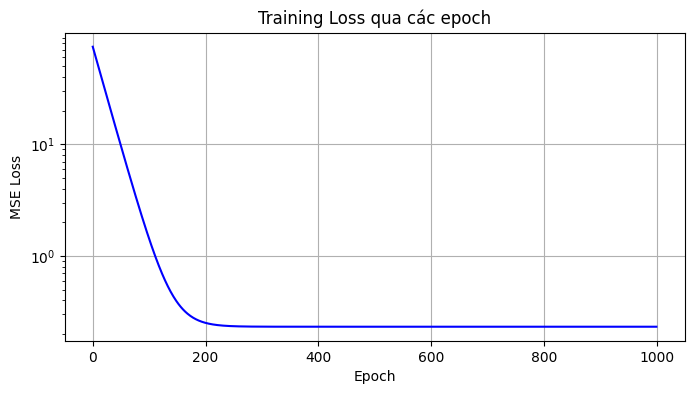

In [6]:
# In tham số đã học được
w_learned = model.linear.weight.item()
b_learned = model.linear.bias.item()

print("=" * 40)
print("Kết quả sau khi train:")
print(f"  Thực tế  : y = 3.0000 * x + 7.0000")
print(f"  Học được : y = {w_learned:.4f} * x + {b_learned:.4f}")
print("=" * 40)

# Vẽ Loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='blue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss qua các epoch')
plt.yscale('log')
plt.grid(True)
plt.show()

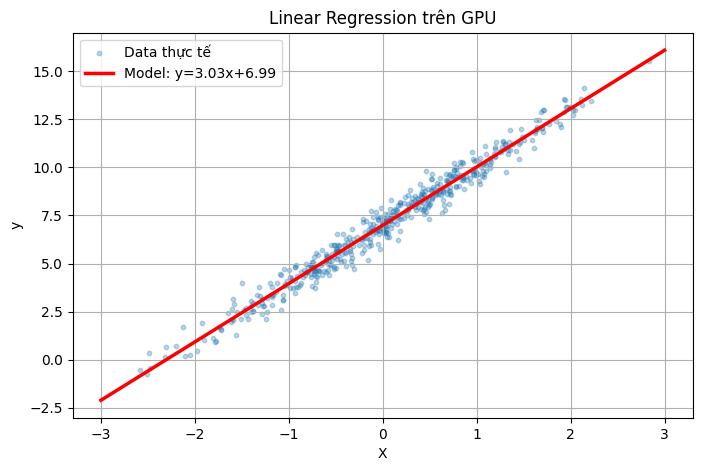

In [7]:
# Vẽ đường hồi quy đã học được
model.eval()
with torch.no_grad():
    X_test = torch.linspace(-3, 3, 100).reshape(-1, 1).to(device)
    y_test  = model(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(X.cpu().numpy(), y.cpu().numpy(), alpha=0.3, s=10, label='Data thực tế')
plt.plot(X_test.cpu().numpy(), y_test.cpu().numpy(),
         color='red', linewidth=2.5, label=f'Model: y={w_learned:.2f}x+{b_learned:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression trên GPU')
plt.legend()
plt.grid(True)
plt.show()

---
## Bước 6: So sánh tốc độ CPU vs GPU

In [8]:
def train_on_device(target_device, n_samples=100_000, epochs=200):
    torch.manual_seed(0)
    X_ = torch.randn(n_samples, 1).to(target_device)
    y_ = (3 * X_ + 7).to(target_device)

    m = LinearRegressionModel().to(target_device)
    opt = torch.optim.SGD(m.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    # Warmup
    for _ in range(5):
        opt.zero_grad()
        loss_fn(m(X_), y_).backward()
        opt.step()

    if target_device.type == 'cuda':
        torch.cuda.synchronize()

    t0 = time.time()
    for _ in range(epochs):
        opt.zero_grad()
        loss_fn(m(X_), y_).backward()
        opt.step()

    if target_device.type == 'cuda':
        torch.cuda.synchronize()

    return time.time() - t0

cpu_device = torch.device('cpu')

print(f"Đang benchmark với 100,000 mẫu, 200 epochs...")
cpu_time = train_on_device(cpu_device)
print(f"CPU: {cpu_time:.3f}s")

if torch.cuda.is_available():
    gpu_time = train_on_device(device)
    print(f"GPU: {gpu_time:.3f}s")
    print(f"\n🚀 GPU nhanh hơn CPU: {cpu_time/gpu_time:.1f}x")
else:
    print("Không có GPU để so sánh")

Đang benchmark với 100,000 mẫu, 200 epochs...
CPU: 0.204s
GPU: 0.137s

🚀 GPU nhanh hơn CPU: 1.5x


---
## Lưu model (vào Google Drive)

Chạy cell dưới để mount Drive trước, sau đó lưu model.

In [9]:
# Mount Google Drive (chạy cell này trên Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    save_path = '/content/drive/MyDrive/linear_regression_model.pth'
except ImportError:
    # Đang chạy local (không phải Colab)
    save_path = 'linear_regression_model.pth'
    print("Đang chạy local, lưu vào thư mục hiện tại")

torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu model tại: {save_path}")

MessageError: User cancelled dfs_ephemeral authorization

In [ ]:
# Load lại model
model_loaded = LinearRegressionModel().to(device)
model_loaded.load_state_dict(torch.load(save_path, map_location=device))
model_loaded.eval()

# Test thử
x_sample = torch.tensor([[2.0]]).to(device)
y_sample  = model_loaded(x_sample)
print(f"Dự đoán với x=2.0 → y = {y_sample.item():.4f}  (lý thuyết: {3*2+7})")